In [1]:
from google.colab import files
uploaded = files.upload()

Saving titanic.zip to titanic.zip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

In [3]:
import os
print(os.listdir())

['.config', 'titanic.zip', 'sample_data']


In [4]:
!unzip titanic.zip
import os
print(os.listdir())

Archive:  titanic.zip
  inflating: gender_submission.csv   
  inflating: test.csv                
  inflating: train.csv               
['.config', 'test.csv', 'titanic.zip', 'gender_submission.csv', 'train.csv', 'sample_data']


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (891, 12)

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
print("Column names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [7]:
# Drop Cabin column (too many missing values)
df.drop('Cabin', axis=1, inplace=True)

# Fill Age with median age
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill Embarked with most common value
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Confirm no missing values
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_4487/726092446.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_4487/726092446.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [12]:
# Convert Sex to numbers (male=0, female=1)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Convert Embarked to numbers
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print("Final columns:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Final columns:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

First 5 rows:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,NaN,22.0,1,0,7.2500,NaN
1,1,1,NaN,38.0,1,0,71.2833,NaN
2,1,3,NaN,26.0,0,0,7.9250,NaN
3,1,1,NaN,35.0,1,0,53.1000,NaN
4,0,3,NaN,35.0,0,0,8.0500,NaN


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('train.csv')

# Clean data
df.drop('Cabin', axis=1, inplace=True)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Feature Engineering
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print("Final columns:", df.columns.tolist())
print("Missing values:", df.isnull().sum().sum())
df.head()

Final columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Missing values: 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


## Step 1 — Load, Explore & Preprocess
- Loaded Titanic dataset with 891 passengers and 12 columns
- Dropped Cabin column (687 missing values — too many to fill)
- Filled Age missing values with median age (28.0)
- Filled Embarked missing values with most common port (S)
- Dropped PassengerId, Name, Ticket (not useful for prediction)
- Converted Sex to numbers (male=0, female=1)
- Converted Embarked to numbers (S=0, C=1, Q=2)
- Result: 0 missing values, all columns are numerical

In [2]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (712, 7)
Testing size: (179, 7)


## Step 2 — Train/Test Split
- Split data into 80% training (712 rows) and 20% testing (179 rows)
- X contains 7 features: Pclass, Sex, Age, SibSp, Parch, Fare, Embarked
- y contains the target: Survived (0 or 1)

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Train Model 1
model1 = LogisticRegression(max_iter=200)
model1.fit(X_train, y_train)

# Evaluate
y_pred1 = model1.predict(X_test)
acc1 = accuracy_score(y_test, y_pred1)
print("Logistic Regression Accuracy:", round(acc1*100, 2), "%")

Logistic Regression Accuracy: 79.89 %


## Step 3 — Model 1: Logistic Regression
- Logistic Regression is a simple classification algorithm
- It predicts probability of survival (0 or 1)
- Accuracy achieved: 79.89%

In [4]:
from sklearn.ensemble import RandomForestClassifier

# Train Model 2
model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X_train, y_train)

# Evaluate
y_pred2 = model2.predict(X_test)
acc2 = accuracy_score(y_test, y_pred2)
print("Random Forest Accuracy:", round(acc2*100, 2), "%")

Random Forest Accuracy: 82.68 %


## Step 3 — Model 2: Random Forest
- Random Forest builds multiple decision trees and combines results
- It is more powerful than Logistic Regression
- Accuracy achieved: 82.68%

In [5]:
from sklearn.neighbors import KNeighborsClassifier

# Train Model 3
model3 = KNeighborsClassifier(n_neighbors=5)
model3.fit(X_train, y_train)

# Evaluate
y_pred3 = model3.predict(X_test)
acc3 = accuracy_score(y_test, y_pred3)
print("KNN Accuracy:", round(acc3*100, 2), "%")

KNN Accuracy: 69.83 %


## Step 3 — Model 3: KNN (K-Nearest Neighbors)
- KNN predicts based on the closest similar passengers
- It performed the worst of the three models
- Accuracy achieved: 69.83%

In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate all metrics
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'KNN'],
    'Accuracy': [round(acc1*100,2), round(acc2*100,2), round(acc3*100,2)],
    'Precision': [round(precision_score(y_test, y_pred1)*100,2),
                  round(precision_score(y_test, y_pred2)*100,2),
                  round(precision_score(y_test, y_pred3)*100,2)],
    'Recall': [round(recall_score(y_test, y_pred1)*100,2),
               round(recall_score(y_test, y_pred2)*100,2),
               round(recall_score(y_test, y_pred3)*100,2)],
    'F1 Score': [round(f1_score(y_test, y_pred1)*100,2),
                 round(f1_score(y_test, y_pred2)*100,2),
                 round(f1_score(y_test, y_pred3)*100,2)]
})

print(results)

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression     79.89      77.14   72.97     75.00
1        Random Forest     82.68      81.16   75.68     78.32
2                  KNN     69.83      67.86   51.35     58.46


## Step 4 — Model Comparison Table
| Model | Accuracy | Precision | Recall | F1 Score |
|-------|----------|-----------|--------|----------|
| Logistic Regression | 79.89% | 77.14% | 72.97% | 75.00% |
| Random Forest | 82.68% | 81.16% | 75.68% | 78.32% |
| KNN | 69.83% | 67.86% | 51.35% | 58.46% |

Random Forest performed best across all metrics!

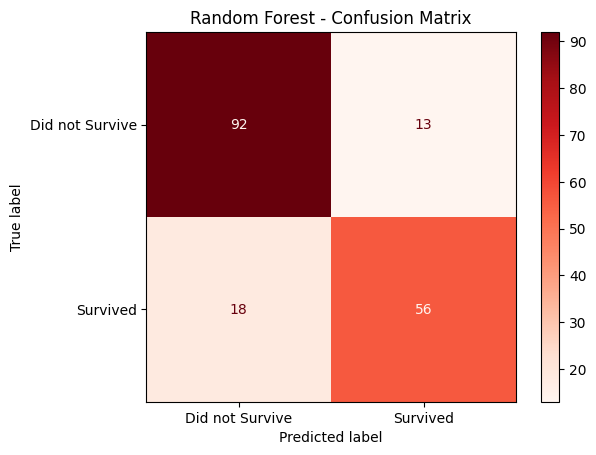

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Did not Survive', 'Survived'])
disp.plot(cmap='Reds')
plt.title('Random Forest - Confusion Matrix')
plt.show()

## Step 5 — Confusion Matrix (Random Forest)
The confusion matrix shows:
- Top left: Correctly predicted "Did not Survive"
- Bottom right: Correctly predicted "Survived"
- Top right & Bottom left: Wrong predictions
Random Forest made the least errors among all 3 models!

## Step 5 — Conclusion

1. Random Forest performed best with 82.68% accuracy, outperforming
   Logistic Regression (79.89%) and KNN (69.83%).

2. Random Forest works better because it combines multiple decision
   trees, reducing errors and handling complex patterns in data.

3. Gender (Sex) and Passenger Class (Pclass) were the most important
   features — females and 1st class passengers survived more.

4. KNN performed worst because it struggles with mixed data types
   like age, fare and categorical variables.

5. Overall the model successfully predicts Titanic survival with
   82.68% accuracy using 7 features.